## Dependencies

In [6]:
from pathlib import Path
import hcpannot
import numpy as np
import neuropythy as ny
from hcpannot.proc import proc
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict
from hcpannot.config import (ventral_raters, subject_list)
import matplotlib.font_manager as fm

results_path = '/data/crcns2021/results'
proc_path = f'{results_path}/proc'
data_path = Path('/data/crcns2021/results/data_branch/save')

In [7]:
%matplotlib inline
fm.fontManager.addfont("HelveticaNeue-Light-08.ttf")

# Additional matplotlib preferences:
font_data = {'family':'sans-serif',
             'sans-serif':['Helvetica Neue'],
             'size': 10}
mpl.rc('font',**font_data)
# we want relatively high-res images, especially when saving to disk.
mpl.rcParams['figure.dpi'] = 72*2
mpl.rcParams['savefig.dpi'] = 72*4

In [8]:
import matplotlib.font_manager as fm

# List all available font names
font_names = sorted({f.name for f in fm.fontManager.ttflist})
for name in font_names:
    if "Helvetica" in name:
        print(name)

Helvetica Neue
HelveticaNeue


## Plot the distribution of the eccentricity of VO vertices for each researcher

In [9]:
subject_list

array([100610, 102311, 102816, 104416, 105923, 108323, 109123, 111312,
       111514, 114823, 115017, 115825, 116726, 118225, 125525, 126426,
       128935, 130114, 130518, 131217, 131722, 132118, 134627, 134829,
       135124, 137128, 140117, 144226, 145834, 146129, 146432, 146735,
       146937, 148133, 150423, 155938, 156334, 157336, 158035, 158136,
       159239, 162935, 164131, 164636, 165436, 167036, 167440, 169040,
       169343, 169444, 169747, 171633, 172130, 173334, 175237, 176542,
       177140, 177645, 177746, 178142, 178243, 178647, 180533, 181232,
       181636, 182436, 182739, 185442, 186949, 187345, 191033, 191336,
       191841, 192439, 192641, 193845, 195041, 196144, 197348, 198653,
       199655, 200210, 200311, 200614, 201515, 203418, 204521, 205220,
       209228, 212419, 214019, 214524, 221319, 233326, 239136, 246133,
       249947, 251833, 257845, 263436, 283543, 318637, 320826, 330324,
       346137, 352738, 360030, 365343, 380036, 381038, 385046, 389357,
      

In [15]:
all_ecc_concat = defaultdict(lambda: defaultdict(list))
all_sarea_concat = defaultdict(lambda: defaultdict(list))

for subject in subject_list:
    for rater in ventral_raters:
        for hemi in ['lh', 'rh']:
            
            try:
                p = proc('ventral', 
                         rater=rater, 
                         sid=subject, 
                         hemisphere=hemi,
                         save_path=proc_path,
                         proc_path=data_path,
                         overwrite=False)

                vo_label = (p['labels'] == 5) | (p['labels'] == 6)
                sub = ny.hcp_subject(subject)

                # extract data:
                ecc = getattr(sub, hemi).prop('prf_eccentricity')
                sarea = getattr(sub, hemi).prop('midgray_surface_area')

                # limit to roi:
                ecc = ecc[vo_label]
                sarea = sarea[vo_label]

                all_ecc_concat[hemi][rater].append(ecc)
                all_sarea_concat[hemi][rater].append(sarea)

                # After you're done with a subject, make sure to free the memory
                # by reloading neuropythy
                ny = ny.reload_neuropythy()
                
            except Exception as e:
                print(e)
            
    print(f'Finished {subject}')

# concatenate data across all subjects
all_ecc_concat = {hemi: {rater: np.concatenate(all_ecc_concat[hemi][rater]) 
                         for rater in all_ecc_concat[hemi].keys()}
                  for hemi in all_ecc_concat.keys()}
all_sarea_concat = {hemi: {rater: np.concatenate(all_sarea_concat[hemi][rater]) 
                         for rater in all_sarea_concat[hemi].keys()}
                  for hemi in all_sarea_concat.keys()}

Finished 100610
Finished 102311
Finished 102816
Finished 104416
Finished 105923
Finished 108323
Finished 109123
Finished 111312
Finished 111514
Finished 114823
Finished 115017
Finished 115825
Finished 116726
Finished 118225
Finished 125525
Finished 126426
Finished 128935
Finished 130114
Finished 130518
Finished 131217
Finished 131722
Finished 132118
Finished 134627
Finished 134829
Finished 135124
Finished 137128
Finished 140117
Finished 144226
Finished 145834
Finished 146129
Finished 146432
Finished 146735
Finished 146937
Finished 148133
Finished 150423
Finished 155938
Finished 156334
Finished 157336
Finished 158035
Finished 158136
Finished 159239
Finished 162935
Finished 164131
Finished 164636
Finished 165436
Finished 167036
Finished 167440
Finished 169040
Finished 169343
Finished 169444
Finished 169747
Finished 171633
Finished 172130
Finished 173334
Finished 175237
Finished 176542
Finished 177140
Finished 177645
Finished 177746
Finished 178142
Finished 178243
Finished 178647
Finished

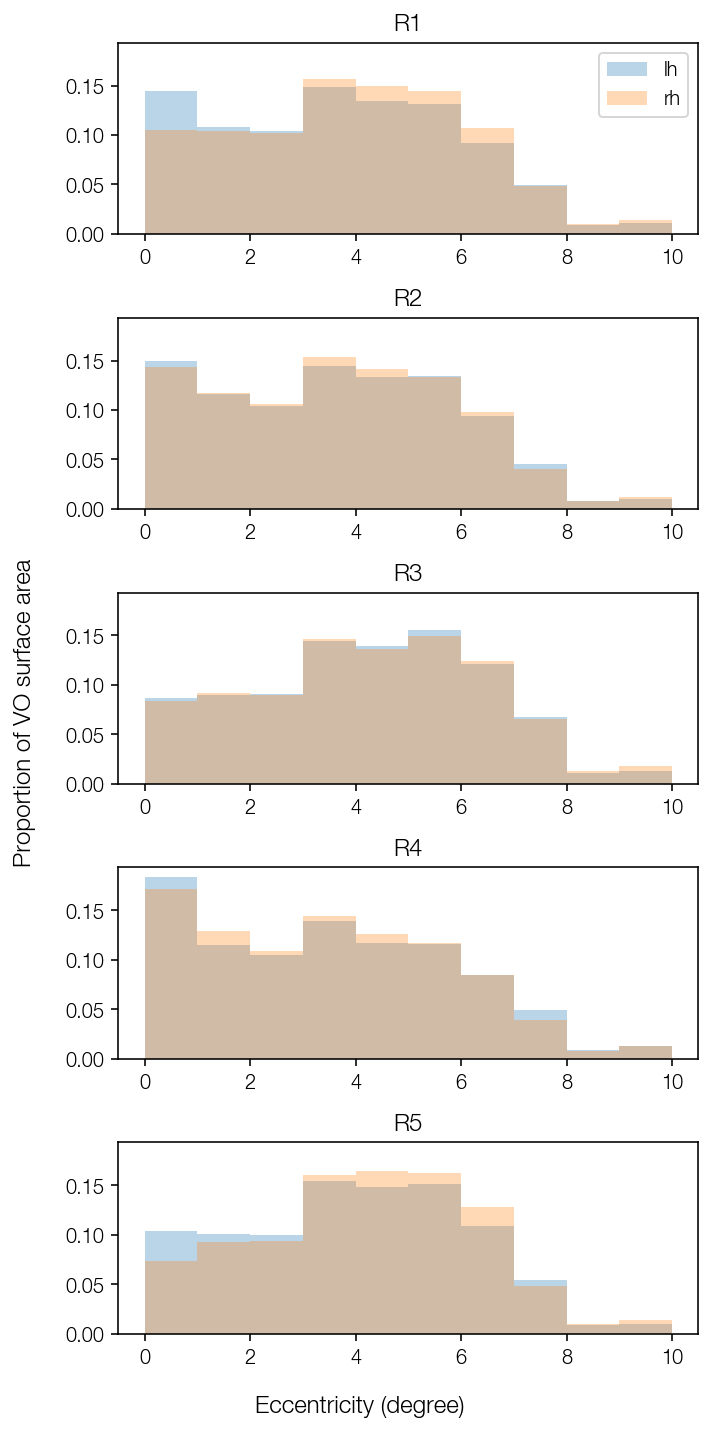

In [16]:
fig, ax = plt.subplots(len(ventral_raters), 1, figsize=(5, 10), sharey=True)

for ii, rater in enumerate(ventral_raters):
    for jj, hemi in enumerate(['lh', 'rh']):
        hist = ax[ii].hist(all_ecc_concat[hemi][rater], 
                           weights=all_sarea_concat[hemi][rater]/np.sum(all_sarea_concat[hemi][rater]),
                          alpha=0.3, label=hemi, bins=10, range=(0,10))
        ax[ii].set_title(f'{rater}')
        
fig.supxlabel('Eccentricity (degree)')
fig.supylabel('Proportion of VO surface area')
fig.tight_layout()
ax[0].legend()

In [17]:
# Dictionary to store proportion area under 1 deg
prop_area_under_1deg = {}

for rater in ventral_raters:
    prop_area_under_1deg[rater] = {}
    for hemi in ['lh', 'rh']:
        ecc = np.array(all_ecc_concat[hemi][rater])
        area = np.array(all_sarea_concat[hemi][rater])
        
        # Normalize surface area to sum to 1
        area_normalized = area / np.sum(area)
        
        # Select where eccentricity < 1
        mask = ecc < 1
        
        # Sum the proportion area under 1°
        proportion = np.sum(area_normalized[mask])
        
        prop_area_under_1deg[rater][hemi] = proportion


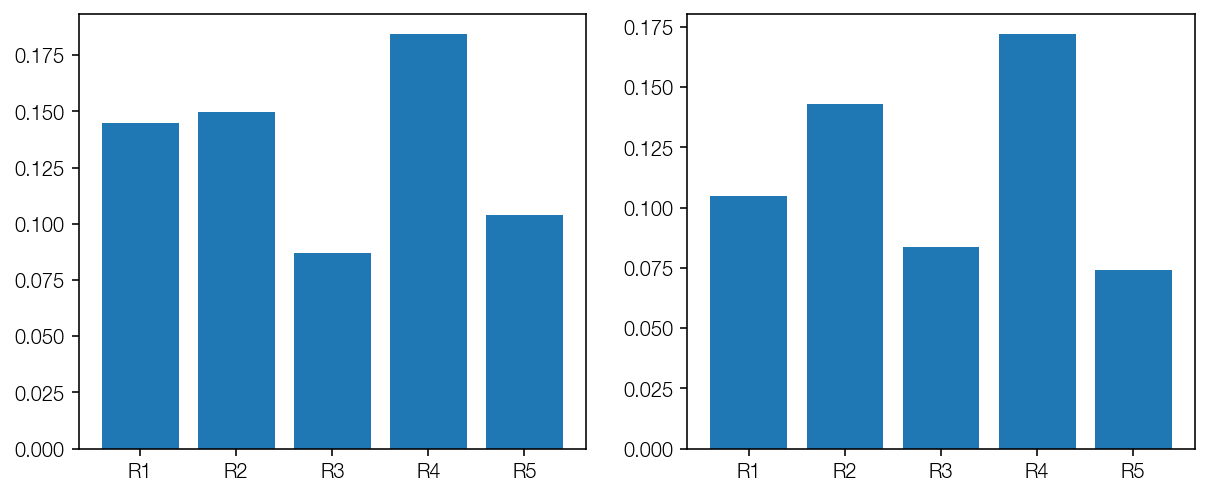

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for ii, hemi in enumerate(['lh', 'rh']):
    ax[ii].bar(ventral_raters, [prop_area_under_1deg[r][hemi] for r in ventral_raters])

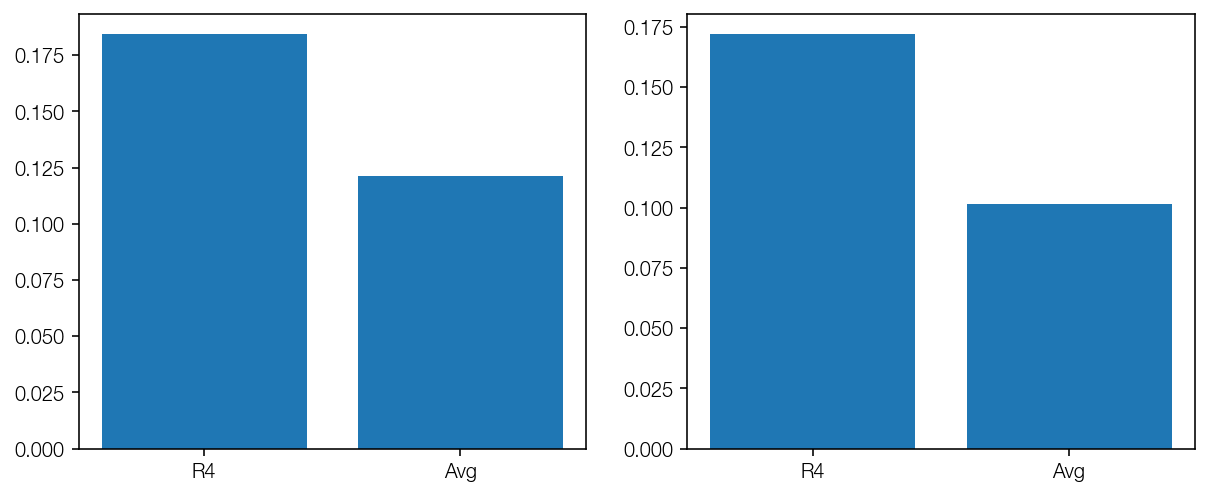

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
raters = ['R4', 'Avg']
for ii, hemi in enumerate(['lh', 'rh']):
    temp_area = [prop_area_under_1deg['R4'][hemi], np.mean([prop_area_under_1deg[r][hemi] for r in ventral_raters if r != 'R4'])]
    ax[ii].bar(raters, temp_area)

In [20]:
raters_hist = defaultdict(dict)

for ii, rater in enumerate(ventral_raters):
    for jj, hemi in enumerate(['lh', 'rh']):
        hist = np.histogram(all_ecc_concat[hemi][rater], 
                           weights=all_sarea_concat[hemi][rater]/np.sum(all_sarea_concat[hemi][rater]),
                           bins=10, range=(0, 10))
        raters_hist[hemi][rater]=hist[0]
        #ax[ii].set_title(f'{rater}')
        
# fig.supxlabel('Eccentricity (degree)')
# fig.supylabel('Proportion of VO surface area')
# fig.tight_layout()
# ax[0].legend()

In [21]:
raters_hist

defaultdict(dict,
            {'lh': {'R1': array([0.14478947, 0.10857033, 0.10443838, 0.14829856, 0.1348116 ,
                     0.13146283, 0.0919321 , 0.04962264, 0.00896815, 0.01135976],
                    dtype=float32),
              'R2': array([0.14990598, 0.11610909, 0.10365555, 0.14451343, 0.1331928 ,
                     0.13462315, 0.0934621 , 0.04576105, 0.0081453 , 0.01052259],
                    dtype=float32),
              'R3': array([0.08715375, 0.09016063, 0.09034732, 0.14469418, 0.139109  ,
                     0.15539911, 0.12154868, 0.06727571, 0.01146235, 0.01333623],
                    dtype=float32),
              'R4': array([0.18420878, 0.11502375, 0.1050653 , 0.13902652, 0.1167909 ,
                     0.11613265, 0.0847159 , 0.04940536, 0.00868901, 0.01250801],
                    dtype=float32),
              'R5': array([0.10384861, 0.1012018 , 0.10016261, 0.15396163, 0.1479645 ,
                     0.15149233, 0.10938872, 0.05405919, 0.00880299, 

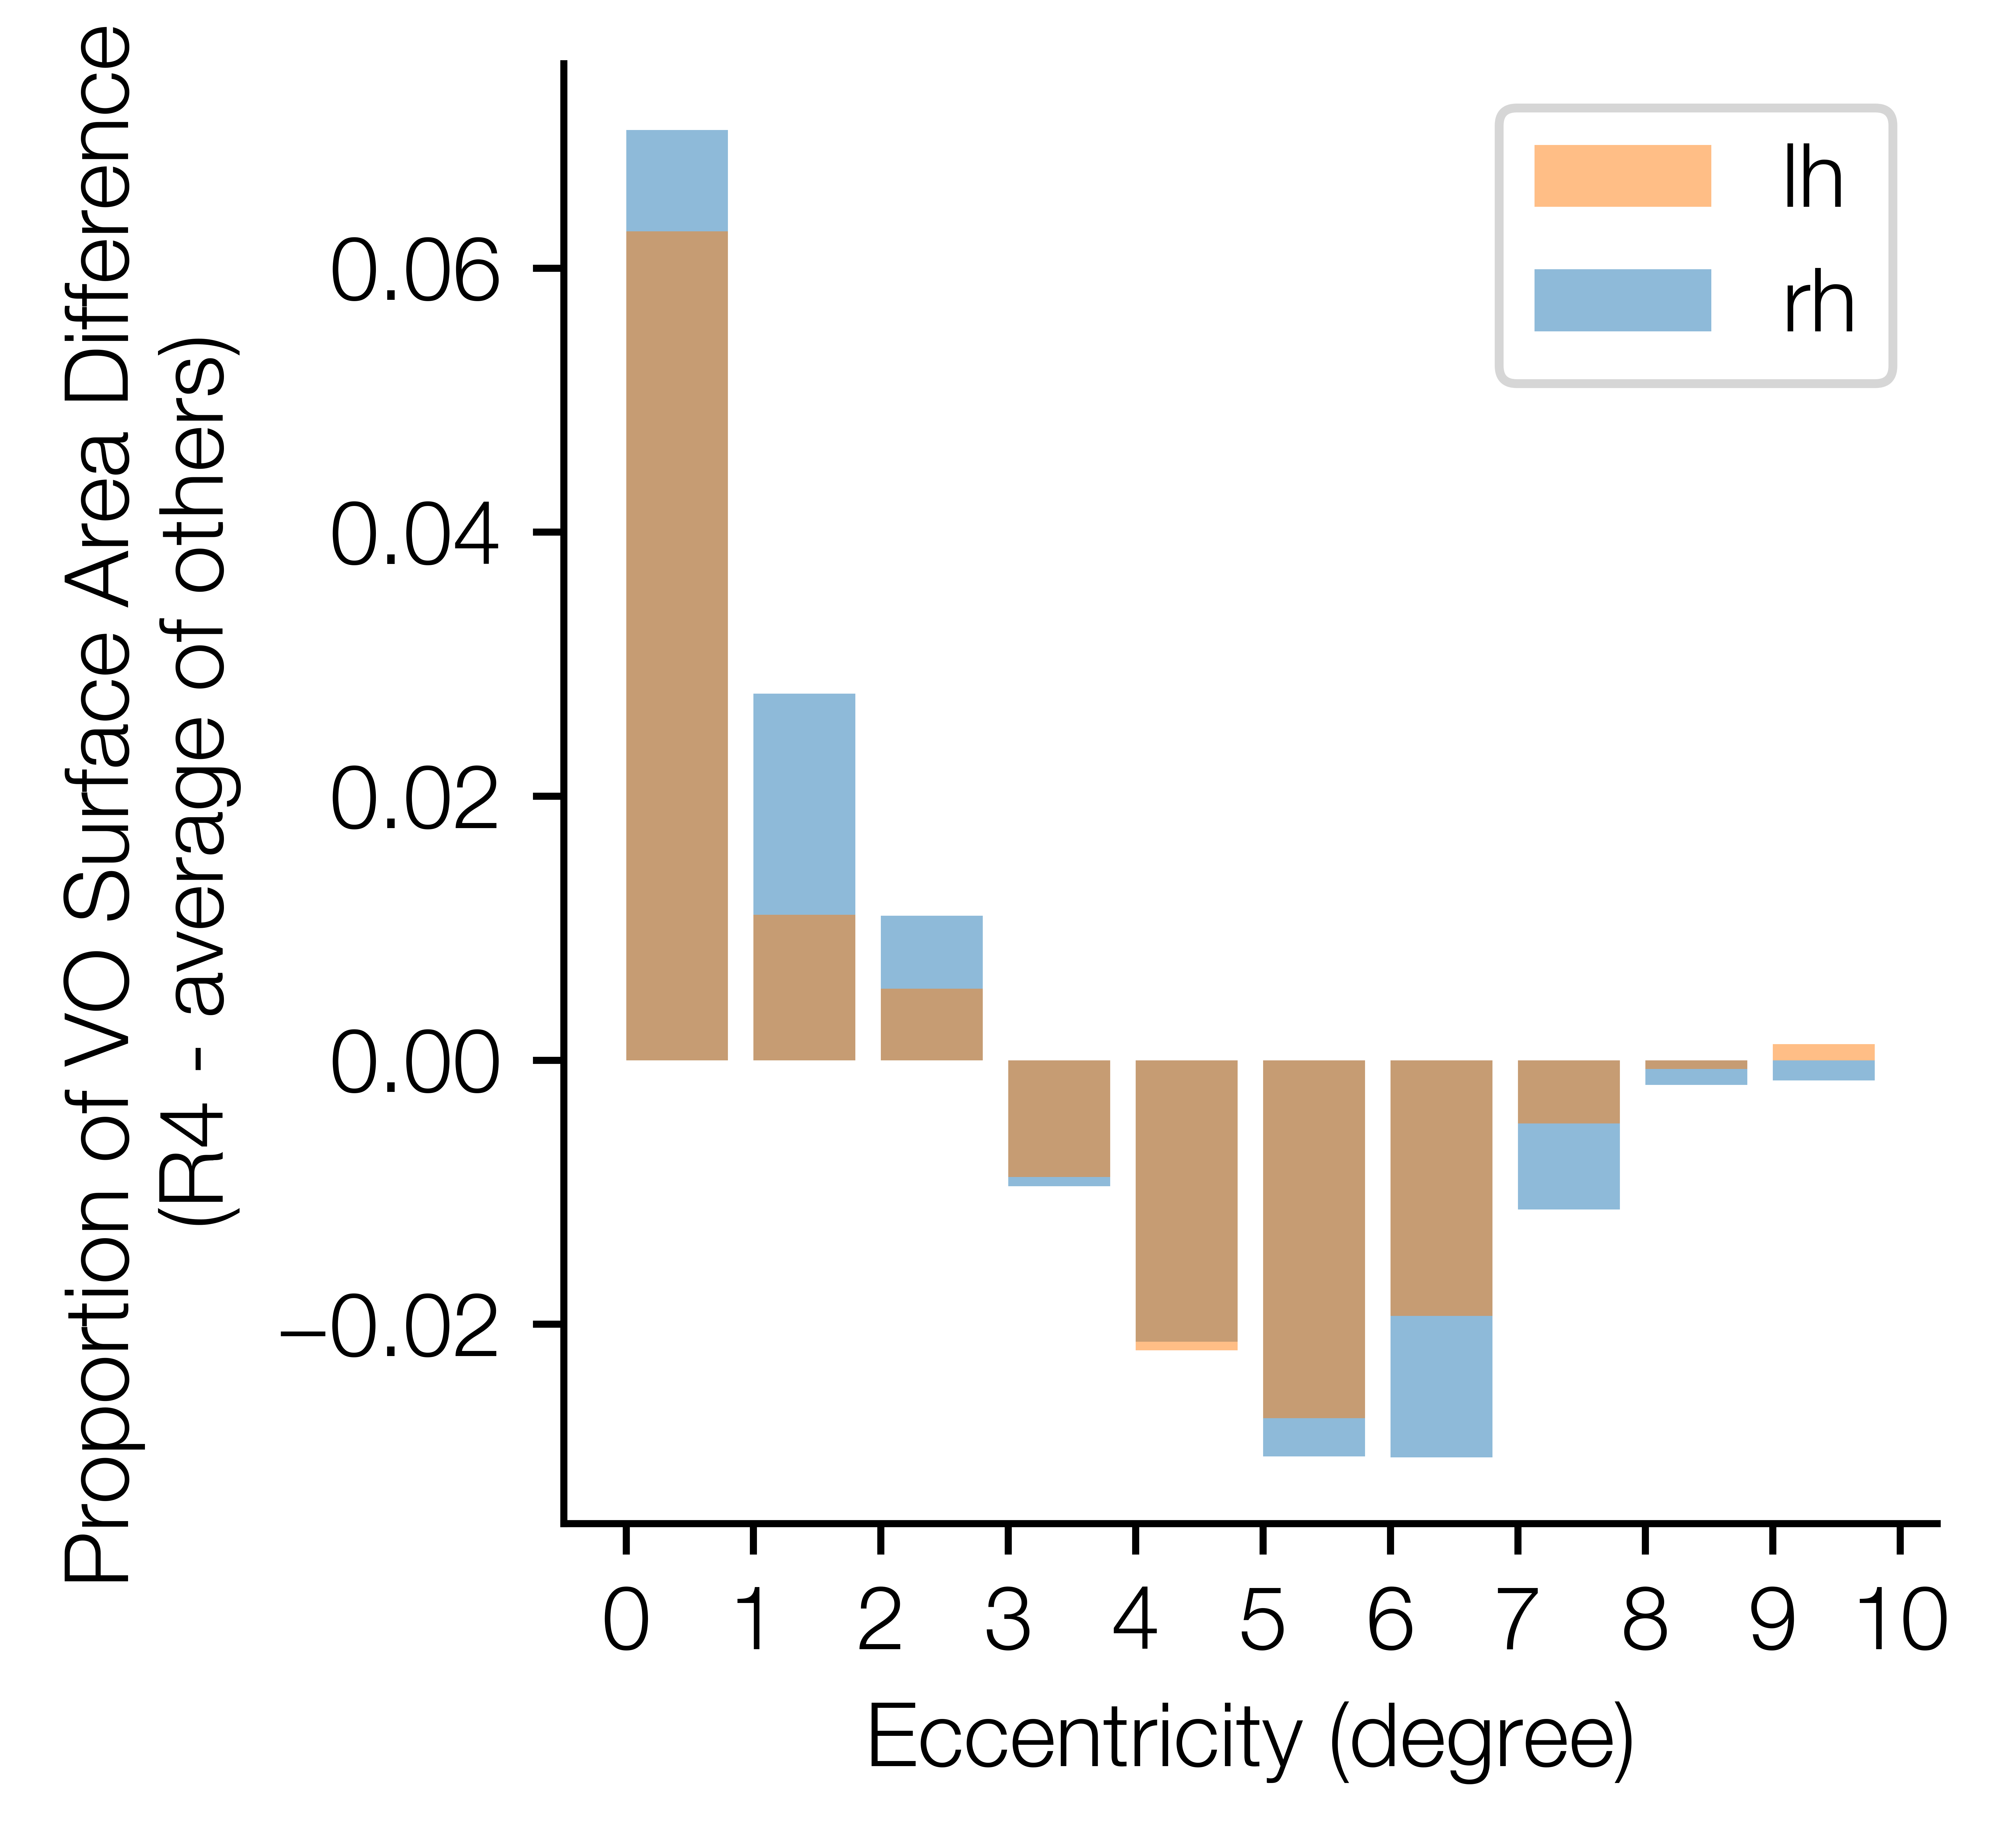

In [22]:
diff_prop_area = {hemi: raters_hist[hemi]['R4'] - np.mean([raters_hist[hemi][r] for r in ventral_raters if r != 'R4'],
                                                          axis=0) 
                  for hemi in ['lh', 'rh']}

fig, ax = plt.subplots(1, 1, figsize=(3.25, 3), sharey=True, dpi=2000)

for hemi in ['rh', 'lh']:
    plt.bar(np.arange(0, 10), height=diff_prop_area[hemi], alpha=0.5, label=hemi, align='edge')
        
        
ax.set_xlabel('Eccentricity (degree)', fontsize=10)
ax.set_ylabel('Proportion of VO Surface Area Difference \n (R4 - average of others)',
             fontsize=10)
fig.tight_layout()

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(0, 11))

# save figure
plt.savefig('images/ecc_dist.pdf', transparent=True)
